# Quadratic Hawkes with an alpha-function synaptic kernel — a non-Markovian temporal convolution

**Showcases:** an **alpha-function synaptic kernel** (a non-Markovian temporal convolution that *rises then decays*, not a bare exponential) combined with a **quadratic Hawkes transfer** $\phi(v)=a\,v^2$. The pipeline carries the colored-in-time filter `g * n` through the MSR-JD machinery as a genuine convolution (double Fourier poles), and the quadratic nonlinearity gives a nonzero curvature $\phi''(v^*)=2a$ — the cubic vertex that drives loop corrections. A size-2 excitatory population; the fields are the spike train $n$ and the synaptic voltage $v$. Here it is run at **tree level** ($\langle nn\rangle$).

$$n_i = \phi(v_i)=a\,v_i^2,\qquad \tau_i\dot v_i = -(v_i-E_i) + \sum_j w_{ij}\,(g_{ij}*n_j),\qquad g_{ij}(t)=\frac{t}{\tau_{g,ij}^2}\,e^{-t/\tau_{g,ij}}\,\Theta(t).$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels (the alpha-function synaptic filter `g`), and the quadratic transfer `phi`.

In [2]:
THEORY = 'quadratic_hawkes_alpha'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  Quadratic Hawkes (alpha-kernel)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : n[E] — spike train; v[E] — synaptic voltage
Response fields: nt, vt
Populations    : E (size 2) — Excitatory
Parameters     :
    Em [E] = [0.8, 0.78]  (positive)
    tau [E] = [10, 9]  (positive)
    taug [E,E] = [[2, 3], [1, 3]]  (positive)
    a [E] = [0.44, 0.44]  (positive)
    w [E,E] = [[0.25, 0.25], [0.2, 0.3]]  (positive)
Mean-field saddle (solved by the pipeline): nstar, vstar
Kernel         : g[E,E] — non-Markovian temporal convolution
Function       : phi(·) — 1-arg transfer
Suggested run  : k=2, max_ell=0

Nonlinear (quadratic) Hawkes process with an ALPHA-FUNCTION synaptic kernel.

A population of ``E`` units carries a spike train ``n`` driven through a
**quadratic** transfer of the synaptic voltage ``v``:

    n_i(t)  = φ(v_i)        wi

"────────────────────────────────────────────────────────────────────────\n  Quadratic Hawkes (alpha-kernel)\n────────────────────────────────────────────────────────────────────────\nDomain         : temporal ODE (time-only)\nFields         : n[E] — spike train; v[E] — synaptic voltage\nResponse fields: nt, vt\nPopulations    : E (size 2) — Excitatory\nParameters     :\n    Em [E] = [0.8, 0.78]  (positive)\n    tau [E] = [10, 9]  (positive)\n    taug [E,E] = [[2, 3], [1, 3]]  (positive)\n    a [E] = [0.44, 0.44]  (positive)\n    w [E,E] = [[0.25, 0.25], [0.2, 0.3]]  (positive)\nMean-field saddle (solved by the pipeline): nstar, vstar\nKernel         : g[E,E] — non-Markovian temporal convolution\nFunction       : phi(·) — 1-arg transfer\nSuggested run  : k=2, max_ell=0\n\nNonlinear (quadratic) Hawkes process with an ALPHA-FUNCTION synaptic kernel.\n\nA population of ``E`` units carries a spike train ``n`` driven through a\n**quadratic** transfer of the synaptic voltage ``v``:\n\n    n_

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The alpha-kernel enters as a genuine non-Markovian convolution `g * n` (double Fourier poles), and the quadratic transfer gives the gain $\phi'(v^*) = 2a v^*$. The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=0,                          # two-point ⟨nn⟩, tree level
    external_fields=[('dn', 1), ('dn', 2)],  # the two neurons' spike trains
    parameters={
        'Em': [0.8, 0.78], 'tau': [10, 9], 'taug': [[2, 3], [1, 3]],
        'a': [0.44, 0.44], 'w': [[0.25, 0.25], [0.2, 0.3]],
    },
    tau_grid=(-20.0, 20.0, 17),              # C(τ) on a lag grid
    parallel=False,                          # serial (no fork in notebooks)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'Quadratic Hawkes (alpha-kernel)'
k      : 2    max_ell : 0
fields : ['dn', 'dv']   spatial_dim : 0
mean-field saddle:  n* = [0.4647 0.4459]   v* = [1.0276 1.0067]
closure n* − a·v*² = [np.float64(-1e-12), np.float64(-4e-12)]


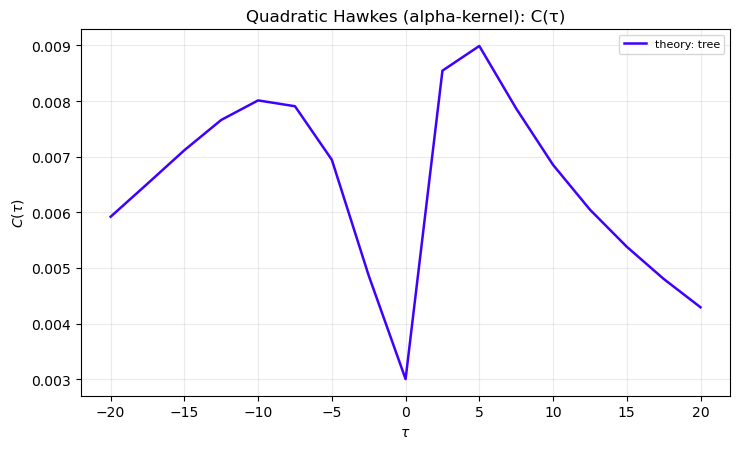

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
mf = res['mf_values']
print('mean-field saddle:  n* =', np.round(mf['nstar'], 4),
      '  v* =', np.round(mf['vstar'], 4))
a = np.asarray(res['_resolved']['parameters']['a'])
print('closure n* − a·v*² =',
      list(np.round(np.asarray(mf['nstar']) - a*np.asarray(mf['vstar'])**2, 12)))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler-step integration of the point process — written from scratch, with no reference to the diagrammatics. The alpha kernel is realised exactly as a **two-stage exponential cascade** ($\alpha = $ two identical low-pass filters convolved, unit DC gain), and the spike rate is the quadratic $\lambda_i = a_i v_i^2$. Overlaying it on the pipeline curve is the validation.

sim: 5 runs × T=8e+05 took 17.1s
sim rates = [0.4679 0.4489]    theory n* = [0.4647 0.4459]
C(0):  sim = 0.00278 (± 0.00052)   theory = 0.00300


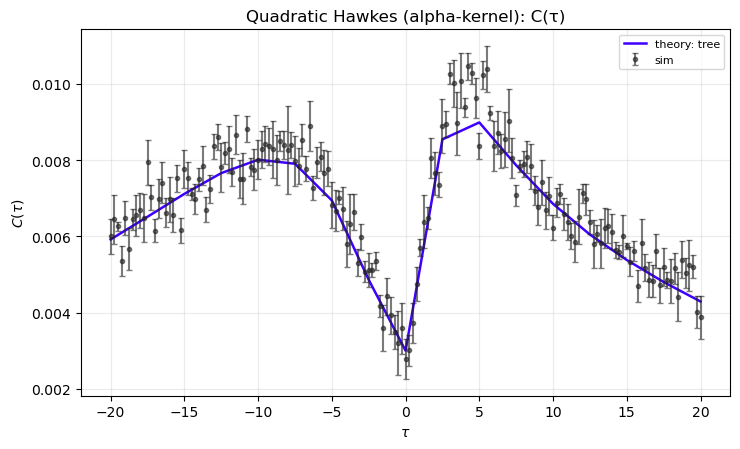

In [5]:
# Independent point-process simulation (direct Euler integration) — NOT the
# pipeline.  Same physical parameters as the theory (read from the model).
from models.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_quad_alpha_numba, build_sim_arrays, flat_index_of)
from models.cumulant_estimator import estimate_kpoint_slices

external_fields = res['_resolved']['external_fields']
fundamental     = res['_resolved']['parameters']
arr = build_sim_arrays(model, fundamental, mf)   # flat per-neuron / per-pair arrays
N, tau_v, a_gain   = arr['N'], arr['tau_v'], arr['a_gain']
E_drive, W         = arr['E_drive'], arr['W']
tau_g_arr, v_init  = arr['tau_g'], arr['v_init']
pop_offsets        = arr['pop_offsets']

# Fast simulation knobs (whole notebook runs in well under a minute).
N_RUNS, T_sim, dt_sim, dt_bin = 5, 8.0e5, 0.01, 0.25
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
pop_indices    = [flat_index_of(model, pop_offsets, ef[0], ef[1])
                  for ef in external_fields]
field_types    = [ef[0] for ef in external_fields]

# k−1 axis-parallel cumulant slices (leg 0 anchored at lag 0; other
# non-anchor legs held at the base point; one slice sweeps each leg j).
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0] * (k - 1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]

# JIT warmup (Sage literals → int()/float() so @njit can type them).
_ = sim_hawkes_multipop_quad_alpha_numba(
    int(1000), float(dt_sim), tau_v, a_gain, E_drive, W, tau_g_arr,
    v_init.copy(), int(bin_size_steps), int(100), int(0))

C_runs, rate_runs = [], []
t0 = time.perf_counter()
for r in range(N_RUNS):
    bc, vb, ts = sim_hawkes_multipop_quad_alpha_numba(
        int(n_steps), float(dt_sim), tau_v, a_gain, E_drive, W, tau_g_arr,
        v_init.copy(), int(bin_size_steps), int(n_bins), int(1234 + r))
    rate_runs.append([float(ts[i]) / T_sim for i in range(N)])
    tau_sim, Cj = estimate_kpoint_slices(
        float(dt_bin_eff), [int(p) for p in pop_indices], field_types,
        base_bins, int(max_lag_bins), binned_counts=bc, voltage_bins=vb)
    C_runs.append(np.asarray(Cj))            # (k−1, n_tau)
C_arr  = np.array(C_runs)
C_sim  = C_arr.mean(axis=0)
C_err  = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
print('sim: %d runs × T=%.0g took %.1fs' % (N_RUNS, T_sim, time.perf_counter() - t0))
print('sim rates =', np.round(np.array(rate_runs).mean(axis=0), 4),
      '   theory n* =', np.round(mf['nstar'], 4))

sim = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}   # 2-D: one row per slice
mid   = len(tau_sim) // 2
C_th0 = float(np.interp(0.0, res['tau_grid'], np.real(res['C_tau'])))
print('C(0):  sim = %.5f (± %.5f)   theory = %.5f'
      % (C_sim[0][mid], C_err[0][mid], C_th0))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The tree-level two-point cumulant $C(\tau)=\langle n\,n\rangle$ carries the **alpha-function synaptic filter** — its rise-then-decay shape (double Fourier poles, not a single exponential) sets the lag structure of the correlator, and the cross-coupling $w_{ij}$ makes it asymmetric in $\tau$. The independent point-process simulation — with the alpha kernel built as a two-stage exponential cascade and the **quadratic** rate $\lambda=a v^2$ — reproduces both the mean-field rates ($n^*=a v^{*2}$) and the $C(\tau)$ curve. Turning on `max_ell=1` would add the 1-loop correction from the cubic vertex $\phi''(v^*)=2a$.